# Modelo de predicción para consumo de combustible

Dataset: **Auto MPG** (UCI Machine Learning Repository)

Metodología: **CRISP-DM**

Modelo: **Árbol de decisión (Decision Tree Regressor)**

## Entendimiento del negocio

El consumo de combustible (**mpg**, millas por galón) es clave para fabricantes y compradores: impacta costos, normativas de eficiencia y decisiones de compra.

**Objetivo del negocio:** predecir el `mpg` de un vehículo a partir de sus características técnicas (cilindros, desplazamiento, potencia, peso, aceleración, año y origen).

**Objetivo de minería de datos:** construir un modelo de regresión (Árbol de Decisión) que prediga `mpg`, evaluando su desempeño con métricas de error (MAE, RMSE) y R².

## Entendimiento de los datos

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_style("whitegrid")

### Correlación o lectura de datos

El archivo `auto-mpg.data` no tiene encabezado y las columnas están separadas por espacios. Los valores faltantes están marcados con `?` (todos en `horsepower`).

In [2]:
columnas = [
    "mpg", "cylinders", "displacement", "horsepower", "weight",
    "acceleration", "model_year", "origin", "car_name"
]

df = pd.read_csv("auto-mpg.data", sep=r"\s+", names=columnas, na_values="?")
df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,car_name
0,18.0,8,307.0,130.0,3504.0,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693.0,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150.0,3436.0,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150.0,3433.0,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140.0,3449.0,10.5,70,1,ford torino


### Descripción de datos

In [3]:
print(f"Filas: {df.shape[0]}, Columnas: {df.shape[1]}")
df.info()

Filas: 398, Columnas: 9
<class 'pandas.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    392 non-null    float64
 4   weight        398 non-null    float64
 5   acceleration  398 non-null    float64
 6   model_year    398 non-null    int64  
 7   origin        398 non-null    int64  
 8   car_name      398 non-null    str    
dtypes: float64(5), int64(3), str(1)
memory usage: 28.1 KB


In [4]:
df.describe()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin
count,398.000000,398.000000,398.000000,392.000000,398.000000,398.000000,398.000000,398.000000
mean,23.514573,5.454774,193.425879,104.469388,2970.424623,15.568090,76.010050,1.572864
std,7.815984,1.701004,104.269838,38.491160,846.841774,2.757689,3.697627,0.802055
min,9.000000,3.000000,68.000000,46.000000,1613.000000,8.000000,70.000000,1.000000
25%,17.500000,4.000000,104.250000,75.000000,2223.750000,13.825000,73.000000,1.000000
50%,23.000000,4.000000,148.500000,93.500000,2803.500000,15.500000,76.000000,1.000000
75%,29.000000,8.000000,262.000000,126.000000,3608.000000,17.175000,79.000000,2.000000
max,46.600000,8.000000,455.000000,230.000000,5140.000000,24.800000,82.000000,3.000000


`mpg` es la variable objetivo (continua). Las variables predictoras son `cylinders`, `displacement`, `horsepower`, `weight`, `acceleration`, `model_year` y `origin`. `car_name` es un identificador único de texto y no se usará como predictor.

### Exploración de datos

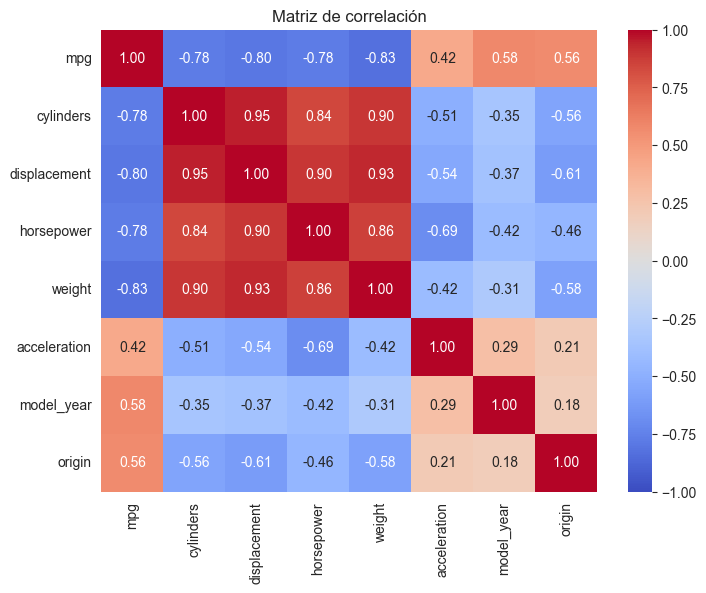

In [5]:
plt.figure(figsize=(8, 6))
corr = df.drop(columns=["car_name"]).corr(numeric_only=True)
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Matriz de correlación")
plt.show()

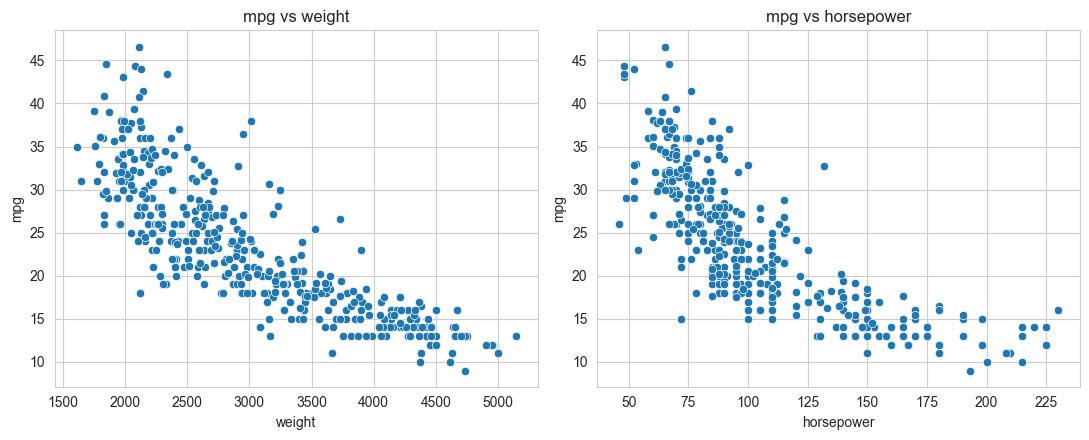

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
sns.scatterplot(data=df, x="weight", y="mpg", ax=axes[0])
sns.scatterplot(data=df, x="horsepower", y="mpg", ax=axes[1])
axes[0].set_title("mpg vs weight")
axes[1].set_title("mpg vs horsepower")
plt.tight_layout()
plt.show()

`weight`, `displacement` y `horsepower` tienen correlación negativa fuerte con `mpg`: a mayor peso/cilindrada/potencia, menor eficiencia. `model_year` correlaciona positivamente (autos más recientes son más eficientes).

### Calidad de datos

In [7]:
print("Valores nulos por columna:")
print(df.isnull().sum())
print(f"\nFilas duplicadas: {df.duplicated().sum()}")

Valores nulos por columna:
mpg             0
cylinders       0
displacement    0
horsepower      6
weight          0
acceleration    0
model_year      0
origin          0
car_name        0
dtype: int64

Filas duplicadas: 0


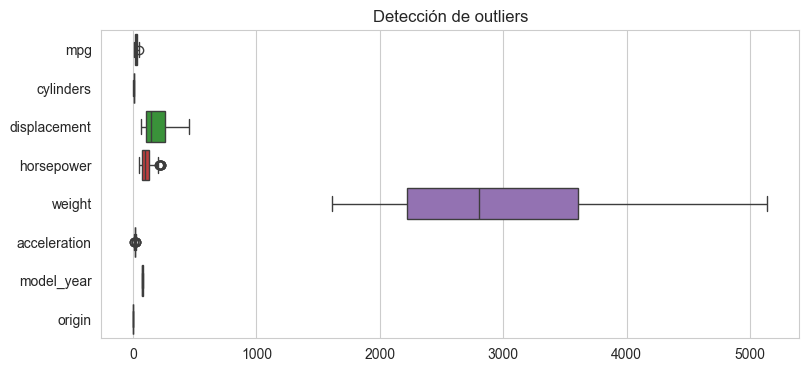

In [8]:
plt.figure(figsize=(9, 4))
sns.boxplot(data=df.drop(columns=["car_name"]), orient="h")
plt.title("Detección de outliers")
plt.show()

`horsepower` tiene 6 valores faltantes (~1.5% del total). No hay filas duplicadas. `acceleration` y `horsepower` muestran algunos valores altos, consistentes con vehículos de alto rendimiento (no se consideran errores).

## Preparación de los datos

1. Eliminar `car_name` (identificador, sin poder predictivo).
2. Imputar los nulos de `horsepower` con la mediana.
3. Separar en entrenamiento (80%) y prueba (20%).

In [9]:
df_prep = df.drop(columns=["car_name"]).copy()
df_prep["horsepower"] = df_prep["horsepower"].fillna(df_prep["horsepower"].median())

X = df_prep.drop(columns=["mpg"])
y = df_prep["mpg"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("X entrenamiento:", X_train.shape, "| X prueba:", X_test.shape)

X entrenamiento: (318, 7) | X prueba: (80, 7)


## Modelo de machine learning: Decision Tree Regressor

Primero se entrena un árbol sin restricciones (parámetros por defecto) y luego uno con la profundidad ajustada, para comparar ambos casos.

In [10]:
modelo_base = DecisionTreeRegressor(random_state=42)
modelo_base.fit(X_train, y_train)

print("Profundidad del árbol:", modelo_base.get_depth())
print("Número de hojas:", modelo_base.get_n_leaves())
print(f"R² en entrenamiento: {modelo_base.score(X_train, y_train):.3f}")
print(f"R² en prueba: {modelo_base.score(X_test, y_test):.3f}")

Profundidad del árbol: 18
Número de hojas: 262
R² en entrenamiento: 1.000
R² en prueba: 0.794


El árbol sin restricciones memoriza el entrenamiento (R²=1.0) pero generaliza peor en prueba: es sobreajuste. Se busca una profundidad más adecuada usando validación cruzada.

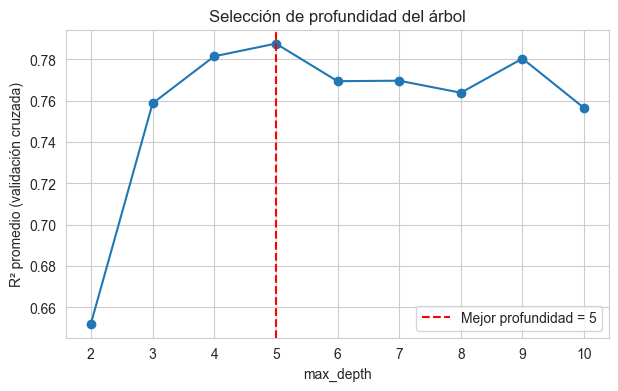

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",5
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max

In [11]:
profundidades = range(2, 11)
scores_cv = [
    cross_val_score(DecisionTreeRegressor(max_depth=d, random_state=42), X_train, y_train, cv=5).mean()
    for d in profundidades
]

mejor_profundidad = profundidades[np.argmax(scores_cv)]

plt.figure(figsize=(7, 4))
plt.plot(list(profundidades), scores_cv, marker="o")
plt.axvline(mejor_profundidad, color="red", linestyle="--", label=f"Mejor profundidad = {mejor_profundidad}")
plt.xlabel("max_depth")
plt.ylabel("R² promedio (validación cruzada)")
plt.title("Selección de profundidad del árbol")
plt.legend()
plt.show()

modelo = DecisionTreeRegressor(max_depth=mejor_profundidad, random_state=42)
modelo.fit(X_train, y_train)

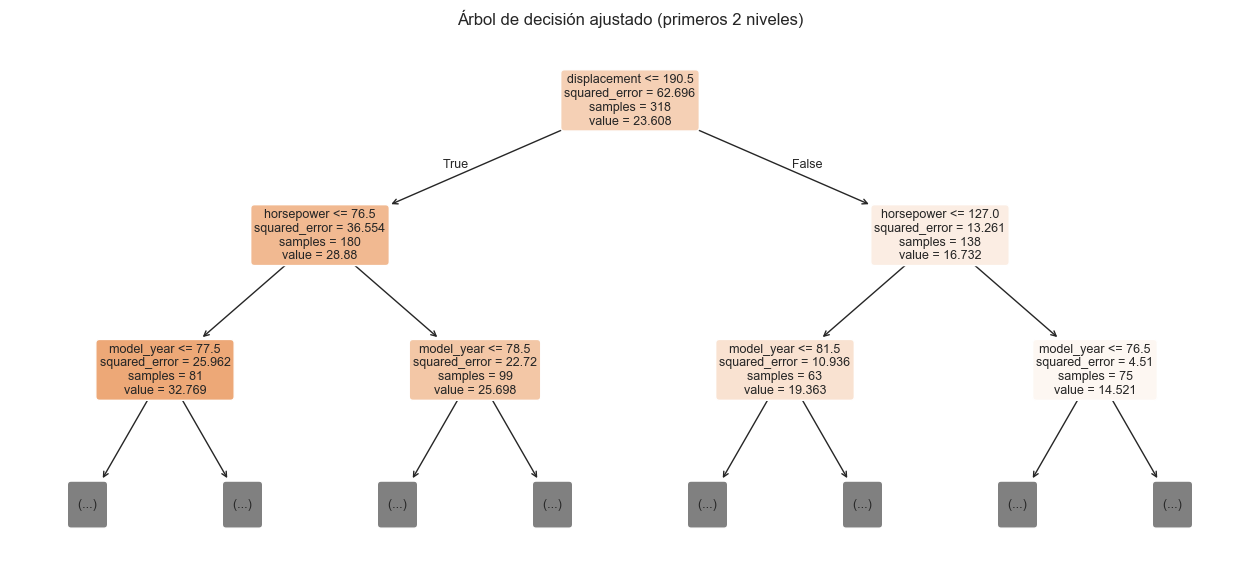

In [12]:
plt.figure(figsize=(16, 7))
plot_tree(modelo, feature_names=X.columns, filled=True, rounded=True, max_depth=2, fontsize=9)
plt.title("Árbol de decisión ajustado (primeros 2 niveles)")
plt.show()

## Evaluación de los resultados

In [13]:
resultados = []
for nombre, mod in [("Base (sin restricción)", modelo_base), (f"Ajustado (max_depth={mejor_profundidad})", modelo)]:
    y_pred = mod.predict(X_test)
    resultados.append({
        "modelo": nombre,
        "MAE": mean_absolute_error(y_test, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_test, y_pred)),
        "R2": r2_score(y_test, y_pred),
    })

pd.DataFrame(resultados)

,modelo,MAE,RMSE,R2
0,Base (sin restricción),2.190000,3.326597,0.794179
1,Ajustado (max_depth=5),2.284156,3.303446,0.797034


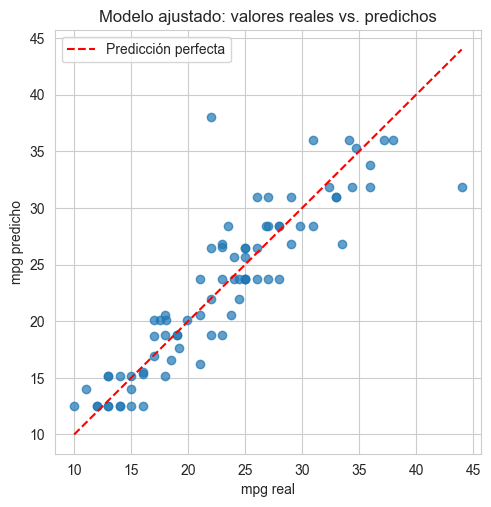

In [14]:
y_pred = modelo.predict(X_test)

plt.figure(figsize=(5.5, 5.5))
plt.scatter(y_test, y_pred, alpha=0.7)
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
plt.plot(lims, lims, "r--", label="Predicción perfecta")
plt.xlabel("mpg real")
plt.ylabel("mpg predicho")
plt.title("Modelo ajustado: valores reales vs. predichos")
plt.legend()
plt.show()

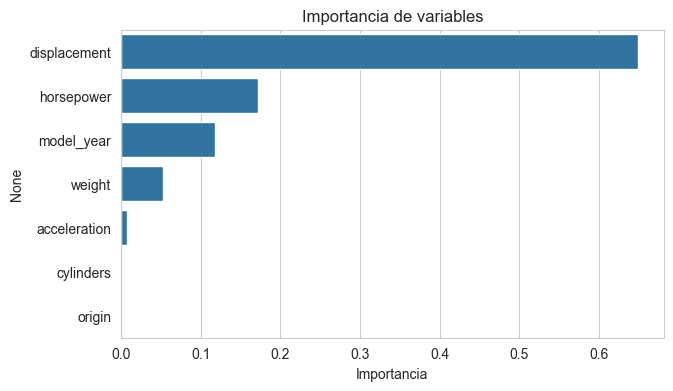

In [15]:
importancias = pd.Series(modelo.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(7, 4))
sns.barplot(x=importancias.values, y=importancias.index)
plt.title("Importancia de variables")
plt.xlabel("Importancia")
plt.show()

El modelo ajustado reduce el sobreajuste del árbol base y mantiene un R² similar o mejor en el conjunto de prueba. `weight`, `displacement` y `model_year` son las variables más influyentes en la predicción de `mpg`, consistente con lo observado en la exploración de datos.

## Conclusiones

- El árbol de decisión con profundidad ajustada por validación cruzada predice el consumo de combustible (`mpg`) con buena precisión (ver MAE, RMSE y R² arriba) y generaliza mejor que el árbol sin restricciones, que sobreajusta los datos de entrenamiento.
- El peso del vehículo (`weight`) y la cilindrada (`displacement`) son los factores técnicos más determinantes del consumo, seguidos del año del modelo (`model_year`), que refleja mejoras tecnológicas a través del tiempo.
- El modelo es interpretable: se pueden visualizar las reglas de decisión, lo que ayuda a explicar qué combinaciones de características producen vehículos más o menos eficientes.
- Como trabajo futuro, se podría comparar contra modelos de ensamble (Random Forest, Gradient Boosting) para ver si mejora la capacidad predictiva.